# Classificação de textos com Jev

Neste notebook retomaremos o corpus **B2W-Reviews01**, com avaliações de produtos em português brasileiro, mas substituiremos o pipeline clássico `TF-IDF + classificador` pelo **Jev**, modelo System One da TypeSafe AI.

A comparação conceitual é importante:

**Pipeline clássico**

`textos rotulados → TF-IDF → treinamento → classificador → previsão`

**Jev**

`texto → state + pergunta tipada → modelo Jev → decisão estruturada`

Neste segundo caso, não treinaremos um modelo com o corpus B2W. O corpus será utilizado como **conjunto de avaliação** para comparar as decisões do Jev com rótulos já existentes.

Documentação principal:

- TypeSafe AI: https://docs.typesafe.ai/introduction
- Quick start: https://docs.typesafe.ai/introduction/quickstart
- Artigo complementar: https://huggingface.co/blog/sora-2/how-to-use-the-jev-ai-model-a-step-by-step-develop


## 1. Por que Jev para classificação?

Jev foi projetado para produzir **decisões estruturadas**, em vez de texto livre. A API oferece três primitivas principais:

- **Choice**: escolher uma alternativa de um conjunto definido;
- **Score**: posicionar um caso em uma escala ordenada;
- **Noul**: avaliar uma proposição binária, retornando um valor entre 0 e 1.

Neste exercício usaremos:

1. **Noul** para estimar se o autor recomendaria o produto;
2. **Score** para estimar a avaliação em uma escala ordenada de 1 a 5 estrelas.

Uma única chamada pode conter as duas perguntas, avaliadas sobre o mesmo texto.


## 2. Instalação

O SDK oficial pode ser instalado diretamente no Google Colab.

> Se o Colab solicitar reinicialização do ambiente após alguma atualização de dependência, execute novamente as células anteriores.


In [ ]:
!pip -q install typesafe-sdk


## 3. Bibliotecas

Além do SDK da TypeSafe, utilizaremos `pandas` para os dados e algumas métricas do `scikit-learn` para comparar as decisões do Jev com os rótulos do B2W.


In [ ]:
import os
import time
from getpass import getpass

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    roc_auc_score
)

from typesafe_sdk import Noul, Score, TypeSafeClient

RANDOM_STATE = 42


## 4. Chave da API

A chave será digitada manualmente durante a execução e armazenada apenas na variável de ambiente da sessão atual do Colab.

O uso de `getpass()` evita que a chave apareça na saída da célula ou fique escrita no código do notebook.


In [ ]:
# apikey_2221421e648866cc42f080efeb27529f865b_ca0162224a4c84a857723d7c29e2975893f3b9b490c416670fd8a00d0bf6c25b

os.environ["TYPESAFE_API_KEY"] = getpass(
    "Digite sua TYPESAFE_API_KEY: "
)

print("Chave registrada apenas na sessão atual do ambiente.")


Digite sua TYPESAFE_API_KEY: ··········
Chave registrada apenas na sessão atual do ambiente.


## 5. Carregando o B2W-Reviews01

Usaremos as mesmas três variáveis do notebook anterior:

- `review_text`: texto da avaliação;
- `recommend_to_a_friend`: recomendaria ou não o produto;
- `overall_rating`: avaliação de 1 a 5 estrelas.

O corpus completo tem mais registros do que precisamos para uma demonstração via API. Inicialmente carregaremos os dados e, depois, selecionaremos uma pequena amostra para avaliação com Jev.


In [ ]:
URL_DADOS = (
    "https://raw.githubusercontent.com/"
    "americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
)

df = pd.read_csv(
    URL_DADOS,
    usecols=[
        "review_text",
        "recommend_to_a_friend",
        "overall_rating"
    ],
    low_memory=False
)

df.head()


,overall_rating,recommend_to_a_friend,review_text
0,4,Yes,Estou contente com a compra entrega rápida o ú...
1,4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ..."
2,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...
3,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...
4,5,Yes,"A entrega foi no prazo, as americanas estão de..."


## 6. Preparação mínima

Aplicaremos a mesma preparação básica utilizada anteriormente:

- remoção de valores ausentes;
- remoção de textos vazios;
- padronização do rótulo de recomendação;
- remoção de duplicatas exatas;
- conversão da nota para inteiro.

Não é necessário aplicar TF-IDF, stemming, lematização ou outras representações: o texto será enviado diretamente como `state`.


In [ ]:
df = df.dropna(
    subset=["review_text", "recommend_to_a_friend", "overall_rating"]
).copy()

df["review_text"] = df["review_text"].astype(str).str.strip()

df["recommend_to_a_friend"] = (
    df["recommend_to_a_friend"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df[df["review_text"].str.len() > 0]

df = df.drop_duplicates(
    subset=["review_text", "recommend_to_a_friend", "overall_rating"]
)

df["overall_rating"] = df["overall_rating"].astype(int)

print("Registros disponíveis:", len(df))
df.head()


Registros disponíveis: 126809


,overall_rating,recommend_to_a_friend,review_text
0,4,yes,Estou contente com a compra entrega rápida o ú...
1,4,yes,"Por apenas R$1994.20,eu consegui comprar esse ..."
2,4,yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...
3,4,yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...
4,5,yes,"A entrega foi no prazo, as americanas estão de..."


## 7. Construindo um pequeno conjunto de avaliação

Cada avaliação enviada ao Jev corresponde a uma chamada à API. Por isso, não precisamos começar com dezenas de milhares de registros.

Vamos criar uma amostra **balanceada por número de estrelas**.

Com o valor padrão de `5`, teremos:

`5 avaliações × 5 classes = 25 avaliações`

Como as duas perguntas serão enviadas juntas, isso corresponde a **25 chamadas à API**, não 50.

Aumente o valor somente quando quiser realizar uma avaliação mais robusta e tiver considerado o custo e os limites de uso da API.


In [ ]:
AMOSTRA_POR_ESTRELA = 5

amostra_jev = (
    df.groupby("overall_rating", group_keys=False)
      .sample(
          n=AMOSTRA_POR_ESTRELA,
          random_state=RANDOM_STATE
      )
      .sample(frac=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

print("Tamanho da amostra:", len(amostra_jev))

amostra_jev[
    ["review_text", "recommend_to_a_friend", "overall_rating"]
].head(10)


Tamanho da amostra: 25


,review_text,recommend_to_a_friend,overall_rating
0,"Bom dia, infelizmente não será possível eu ava...",no,2
1,Não recebi a bolsa preta que diz que acompanha...,no,4
2,"produto veio aberto,com outra cor e marca dife...",no,1
3,Produto excelente de boa qualidade sem problem...,yes,5
4,"o computador tem um designer bem bonito mesmo,...",no,3
5,Tem produto melhor no mercado. Demora muito li...,no,2
6,É um bom produto mas não é muito potente. Não ...,yes,3
7,"Não recomendo, pois comprei pq achei baratinho...",no,1
8,"A câmera e a edição são ótimas, amadores da fo...",yes,5
9,nao informa se e branco frio ou branco quente ...,yes,2


In [ ]:
amostra_jev["overall_rating"].value_counts().sort_index()


,count
overall_rating,
1,5
2,5
3,5
4,5
5,5


## 8. Definindo as perguntas para o Jev

Agora definimos as decisões que o modelo deverá produzir.

### Pergunta 1 — Noul

Queremos avaliar a proposição:

> O autor desta avaliação recomendaria o produto a um amigo?

O resultado `noul` varia de `0` a `1` e pode ser interpretado como o sinal probabilístico associado à proposição.

### Pergunta 2 — Score

As estrelas formam uma escala **ordenada**, portanto `Score` é mais apropriado que tratar 1–5 como categorias sem relação entre si.

Os cinco níveis são descritos semanticamente. Internamente, o Jev os indexa de `0` a `4`; posteriormente converteremos esses níveis novamente para estrelas de `1` a `5`.


In [ ]:
PERGUNTAS_JEV = {
    "recomendaria": Noul(
        instructions=(
            "Com base apenas no texto desta avaliação, "
            "o autor provavelmente recomendaria o produto a um amigo?"
        )
    ),
    "estrelas": Score(
        instructions=(
            "Qual nível de satisfação com o produto é expresso "
            "nesta avaliação?"
        ),
        criteria=[
            (
                "Avaliação fortemente negativa: produto considerado muito ruim, "
                "inadequado, defeituoso ou causador de forte insatisfação."
            ),
            (
                "Avaliação predominantemente negativa: há insatisfação clara, "
                "embora possa existir algum aspecto aceitável ou funcionamento parcial."
            ),
            (
                "Avaliação intermediária ou mista: combina aspectos positivos e "
                "negativos, ou expressa satisfação apenas moderada."
            ),
            (
                "Avaliação predominantemente positiva: o produto atende bem às "
                "expectativas, mas há alguma ressalva, limitação ou crítica secundária."
            ),
            (
                "Avaliação fortemente positiva: produto considerado excelente, "
                "muito satisfatório ou claramente recomendável, sem ressalvas relevantes."
            ),
        ]
    ),
}

PERGUNTAS_JEV


{'recomendaria': Noul(type='noul', instructions='Com base apenas no texto desta avaliação, o autor provavelmente recomendaria o produto a um amigo?', criteria=None),
 'estrelas': Score(type='score', instructions='Qual nível de satisfação com o produto é expresso nesta avaliação?', criteria=['Avaliação fortemente negativa: produto considerado muito ruim, inadequado, defeituoso ou causador de forte insatisfação.', 'Avaliação predominantemente negativa: há insatisfação clara, embora possa existir algum aspecto aceitável ou funcionamento parcial.', 'Avaliação intermediária ou mista: combina aspectos positivos e negativos, ou expressa satisfação apenas moderada.', 'Avaliação predominantemente positiva: o produto atende bem às expectativas, mas há alguma ressalva, limitação ou crítica secundária.', 'Avaliação fortemente positiva: produto considerado excelente, muito satisfatório ou claramente recomendável, sem ressalvas relevantes.'])}

## 9. Primeira chamada: inspecionando uma resposta

Antes de processar toda a amostra, faremos uma única chamada.

Isso permite verificar:

- se a chave está funcionando;
- a estrutura da resposta;
- o valor de `noul`;
- o `score`;
- as probabilidades dos cinco níveis;
- a confiança associada ao `Score`.


In [ ]:
texto_exemplo = amostra_jev.loc[0, "review_text"]

print("Texto:")
print(texto_exemplo)

with TypeSafeClient() as client:
    resposta_exemplo = client.system_one(
        state=texto_exemplo,
        questions=PERGUNTAS_JEV
    )


Texto:
Bom dia, infelizmente não será possível eu avaliar o produto. Pois até o exato momento não recebi o produto ainda... Gostaria de uma posição da Americanas.


In [ ]:
print(
    "Probabilidade de recomendar:",
    resposta_exemplo.answers["recomendaria"].noul
)

print(
    "Score de satisfação:",
    resposta_exemplo.answers["estrelas"].score
)

print(
    "Confiança do Score:",
    resposta_exemplo.answers["estrelas"].confidence
)

print(
    "Probabilidades por nível:",
    resposta_exemplo.answers["estrelas"].probabilities
)


Probabilidade de recomendar: 0.12
Score de satisfação: 1.05
Confiança do Score: 0.8
Probabilidades por nível: {0: 0.09, 1: 0.77, 2: 0.14, 3: 0.0, 4: 0.0}


### Interpretando o Score

Com cinco níveis, o `Score` varia de `0` a `4`.

Podemos converter sua posição para a escala de estrelas:

`estrelas contínuas = score + 1`

Para obter uma **classe discreta**, usaremos o nível com maior probabilidade:

`classe prevista = nível mais provável + 1`

Manteremos as duas informações:

- o valor contínuo, que preserva a posição entre níveis;
- a classe discreta, que permite construir matriz de confusão e calcular acurácia.


In [ ]:
resposta_score = resposta_exemplo.answers["estrelas"]

nivel_mais_provavel = max(
    resposta_score.probabilities,
    key=resposta_score.probabilities.get
)

estrela_prevista = int(nivel_mais_provavel) + 1
estrela_continua = resposta_score.score + 1

print("Estrela prevista:", estrela_prevista)
print("Posição contínua na escala:", round(estrela_continua, 3))


Estrela prevista: 2
Posição contínua na escala: 2.05


## 10. Função de classificação

Vamos encapsular a chamada à API em uma função.

Para cada texto, ela retornará:

- probabilidade de recomendação;
- classe binária prevista (`yes` / `no`);
- score contínuo de estrelas;
- classe de estrelas mais provável;
- confiança do Score;
- distribuição de probabilidades entre 1 e 5 estrelas.

O limiar binário será inicialmente `0.5`. Posteriormente poderíamos estudar outros limiares com base no desempenho observado.


In [ ]:
LIMIAR_RECOMENDACAO = 0.5

def classificar_com_jev(texto, client):
    resposta = client.system_one(
        state=texto,
        questions=PERGUNTAS_JEV
    )

    resposta_recomendacao = resposta.answers["recomendaria"]
    resposta_estrelas = resposta.answers["estrelas"]

    prob_recomendacao = float(resposta_recomendacao.noul)

    recomendacao_prevista = (
        "yes"
        if prob_recomendacao >= LIMIAR_RECOMENDACAO
        else "no"
    )

    probabilidades_estrelas = dict(
        resposta_estrelas.probabilities
    )

    nivel_mais_provavel = max(
        probabilidades_estrelas,
        key=probabilidades_estrelas.get
    )

    estrela_prevista = int(nivel_mais_provavel) + 1
    estrela_score = float(resposta_estrelas.score) + 1

    return {
        "jev_prob_recomendacao": prob_recomendacao,
        "jev_recomendacao": recomendacao_prevista,
        "jev_estrela_score": estrela_score,
        "jev_estrela": estrela_prevista,
        "jev_confianca_estrelas": float(
            resposta_estrelas.confidence
        ),
        **{
            f"jev_prob_{int(nivel) + 1}_estrela":
                float(probabilidade)
            for nivel, probabilidade
            in probabilidades_estrelas.items()
        }
    }


## 11. Aplicando Jev à amostra

Agora percorreremos a amostra selecionada.

A execução é propositalmente sequencial para tornar o fluxo fácil de acompanhar em aula. O pequeno intervalo entre chamadas pode ser ajustado se necessário.

Se ocorrer um erro em uma avaliação, ele será registrado na coluna `erro_jev` e o notebook continuará com os demais casos.


In [ ]:
INTERVALO_ENTRE_CHAMADAS = 0.2

resultados_api = []

with TypeSafeClient() as client:
    for indice, linha in amostra_jev.iterrows():
        try:
            resultado = classificar_com_jev(
                linha["review_text"],
                client
            )
            resultado["erro_jev"] = None

        except Exception as erro:
            resultado = {
                "jev_prob_recomendacao": None,
                "jev_recomendacao": None,
                "jev_estrela_score": None,
                "jev_estrela": None,
                "jev_confianca_estrelas": None,
                "jev_prob_1_estrela": None,
                "jev_prob_2_estrela": None,
                "jev_prob_3_estrela": None,
                "jev_prob_4_estrela": None,
                "jev_prob_5_estrela": None,
                "erro_jev": str(erro)
            }

        resultados_api.append(resultado)

        print(
            f"{indice + 1}/{len(amostra_jev)} concluído",
            end="\r"
        )

        time.sleep(INTERVALO_ENTRE_CHAMADAS)

print("\nProcessamento concluído.")


25/25 concluído
Processamento concluído.


## 12. Organizando os resultados

Juntaremos os rótulos originais do B2W às decisões produzidas pelo Jev.

A partir daqui, voltamos a uma lógica familiar de avaliação de classificadores: temos valores reais e valores previstos.


In [ ]:
resultados_jev = pd.concat(
    [
        amostra_jev.reset_index(drop=True),
        pd.DataFrame(resultados_api)
    ],
    axis=1
)

resultados_validos = resultados_jev[
    resultados_jev["erro_jev"].isna()
].copy()

print(
    "Casos avaliados com sucesso:",
    len(resultados_validos),
    "/",
    len(resultados_jev)
)

resultados_validos.head()


Casos avaliados com sucesso: 25 / 25


,overall_rating,recommend_to_a_friend,review_text,jev_prob_recomendacao,jev_recomendacao,jev_estrela_score,jev_estrela,jev_confianca_estrelas,jev_prob_1_estrela,jev_prob_2_estrela,jev_prob_3_estrela,jev_prob_4_estrela,jev_prob_5_estrela,erro_jev
0,2,no,"Bom dia, infelizmente não será possível eu ava...",0.13,no,2.09,2,0.79,0.08,0.75,0.17,0.0,0.0,None
1,4,no,Não recebi a bolsa preta que diz que acompanha...,0.15,no,1.46,1,0.62,0.54,0.46,0.00,0.0,0.0,None
2,1,no,"produto veio aberto,com outra cor e marca dife...",0.06,no,1.03,1,0.98,0.97,0.03,0.00,0.0,0.0,None
3,5,yes,Produto excelente de boa qualidade sem problem...,0.96,yes,5.00,5,1.00,0.00,0.00,0.00,0.0,1.0,None
4,3,no,"o computador tem um designer bem bonito mesmo,...",0.24,no,2.56,3,0.63,0.00,0.44,0.56,0.0,0.0,None


In [ ]:
resultados_jev.loc[
    resultados_jev["erro_jev"].notna(),
    ["review_text", "erro_jev"]
].head()


,review_text,erro_jev


## 13. Avaliação da decisão binária

Para tornar o `Noul` comparável ao rótulo do corpus:

- `noul >= 0.5` → `yes`;
- `noul < 0.5` → `no`.

Calcularemos:

- acurácia;
- precision, recall e F1;
- matriz de confusão;
- ROC AUC utilizando diretamente o valor contínuo retornado pelo `Noul`.

O valor de 0.5 é apenas um ponto de partida. Um limiar adequado deve ser escolhido empiricamente para o domínio de aplicação.


In [ ]:
y_true_bin = resultados_validos["recommend_to_a_friend"]
y_pred_bin = resultados_validos["jev_recomendacao"]

print(
    f"Acurácia: "
    f"{accuracy_score(y_true_bin, y_pred_bin):.3f}"
)

print("\nRelatório de classificação:")
print(
    classification_report(
        y_true_bin,
        y_pred_bin,
        digits=3,
        zero_division=0
    )
)


Acurácia: 0.920

Relatório de classificação:
              precision    recall  f1-score   support

          no      0.846     1.000     0.917        11
         yes      1.000     0.857     0.923        14

    accuracy                          0.920        25
   macro avg      0.923     0.929     0.920        25
weighted avg      0.932     0.920     0.920        25



In [ ]:
if y_true_bin.nunique() == 2:
    y_true_auc = (y_true_bin == "yes").astype(int)

    auc = roc_auc_score(
        y_true_auc,
        resultados_validos["jev_prob_recomendacao"]
    )

    print(f"ROC AUC: {auc:.3f}")
else:
    print(
        "ROC AUC não calculada: "
        "a amostra não contém as duas classes."
    )


ROC AUC: 1.000


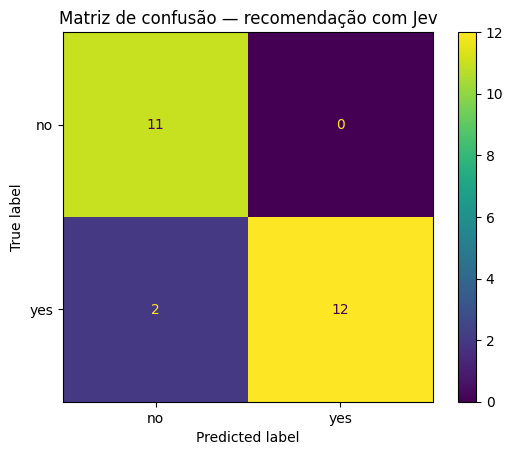

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_true_bin,
    y_pred_bin
)

plt.title("Matriz de confusão — recomendação com Jev")
plt.show()


## 14. Avaliação da escala de estrelas

Aqui podemos avaliar o resultado de duas maneiras.

### Como classificação

Usamos o nível de maior probabilidade como a estrela prevista e calculamos acurácia, métricas por classe e matriz de confusão.

### Como escala ordenada

Usamos o `score + 1`, que pode assumir valores intermediários, e calculamos o erro absoluto médio em relação às estrelas reais.

Essa segunda análise aproveita uma informação que seria descartada se tratássemos as cinco estrelas apenas como categorias independentes.


In [ ]:
y_true_multi = resultados_validos["overall_rating"]
y_pred_multi = resultados_validos["jev_estrela"]

print(
    f"Acurácia: "
    f"{accuracy_score(y_true_multi, y_pred_multi):.3f}"
)

print("\nRelatório de classificação:")
print(
    classification_report(
        y_true_multi,
        y_pred_multi,
        labels=[1, 2, 3, 4, 5],
        digits=3,
        zero_division=0
    )
)


Acurácia: 0.680

Relatório de classificação:
              precision    recall  f1-score   support

           1      0.714     1.000     0.833         5
           2      1.000     0.800     0.889         5
           3      0.750     0.600     0.667         5
           4      0.333     0.200     0.250         5
           5      0.571     0.800     0.667         5

    accuracy                          0.680        25
   macro avg      0.674     0.680     0.661        25
weighted avg      0.674     0.680     0.661        25



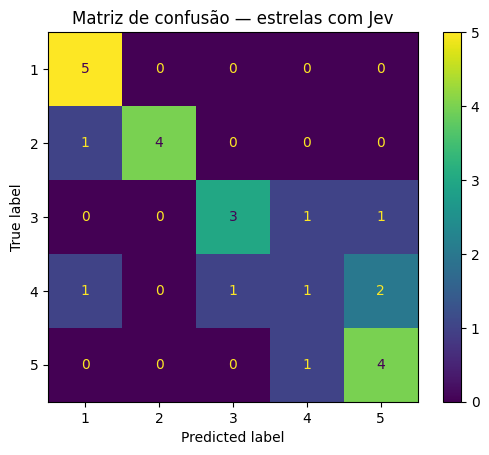

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_true_multi,
    y_pred_multi,
    labels=[1, 2, 3, 4, 5]
)

plt.title("Matriz de confusão — estrelas com Jev")
plt.show()


In [ ]:
mae_score = mean_absolute_error(
    resultados_validos["overall_rating"],
    resultados_validos["jev_estrela_score"]
)

print(
    "Erro absoluto médio usando o Score contínuo:",
    round(mae_score, 3)
)


Erro absoluto médio usando o Score contínuo: 0.468


## 15. Confiança e ambiguidade

O `Score` devolve também uma medida de **confiança**, derivada da concentração ou dispersão da distribuição de probabilidades entre os níveis.

Isso permite identificar avaliações semanticamente ambíguas.

Importante: **confiança não é sinônimo de correção**. Uma resposta pode ter alta confiança e ainda estar errada em relação ao rótulo do corpus.

Vamos examinar primeiro os casos de menor confiança.


In [ ]:
resultados_validos[
    [
        "review_text",
        "overall_rating",
        "jev_estrela",
        "jev_estrela_score",
        "jev_confianca_estrelas"
    ]
].sort_values(
    "jev_confianca_estrelas"
).head(10)


,review_text,overall_rating,jev_estrela,jev_estrela_score,jev_confianca_estrelas
1,Não recebi a bolsa preta que diz que acompanha...,4,1,1.46,0.62
4,"o computador tem um designer bem bonito mesmo,...",3,3,2.56,0.63
6,É um bom produto mas não é muito potente. Não ...,3,3,3.44,0.63
8,"A câmera e a edição são ótimas, amadores da fo...",5,4,4.44,0.63
22,"É um bom celular, vale o custo benefício. A co...",3,3,3.44,0.63
16,Poderia ligar para o consumidor na hora em que...,4,3,3.09,0.70
5,Tem produto melhor no mercado. Demora muito li...,2,2,1.73,0.73
0,"Bom dia, infelizmente não será possível eu ava...",2,2,2.09,0.79
9,nao informa se e branco frio ou branco quente ...,2,2,2.11,0.89
21,"Produto faz o que propõe, estou satisfeita. As...",3,4,3.88,0.90


## 16. Examinando os erros

Como no modelo TF-IDF, observar exemplos concretos é essencial.

A diferença é que agora podemos examinar também:

- a posição contínua do `Score`;
- a distribuição entre os cinco níveis;
- a confiança da decisão.

Essas informações ajudam a distinguir um erro muito seguro de uma decisão realmente ambígua.


In [ ]:
erros_estrelas = resultados_validos[
    resultados_validos["overall_rating"]
    != resultados_validos["jev_estrela"]
].copy()

erros_estrelas["distancia"] = (
    erros_estrelas["overall_rating"]
    - erros_estrelas["jev_estrela"]
).abs()

erros_estrelas[
    [
        "review_text",
        "overall_rating",
        "jev_estrela",
        "jev_estrela_score",
        "jev_confianca_estrelas",
        "distancia"
    ]
].sort_values(
    ["distancia", "jev_confianca_estrelas"],
    ascending=[False, False]
).head(15)


,review_text,overall_rating,jev_estrela,jev_estrela_score,jev_confianca_estrelas,distancia
1,Não recebi a bolsa preta que diz que acompanha...,4,1,1.46,0.62,3
11,Chegou muito rápido gostei é recomendo produto...,3,5,5.00,1.00,2
18,Compre sem medo . Ótimo investimento! A parte...,4,5,4.97,0.98,1
21,"Produto faz o que propõe, estou satisfeita. As...",3,4,3.88,0.90,1
23,"gostei do produto, veio como eu esperava e den...",4,5,4.88,0.90,1
24,Não tenho como avaliar um produto que não rece...,2,1,1.12,0.90,1
16,Poderia ligar para o consumidor na hora em que...,4,3,3.09,0.70,1
8,"A câmera e a edição são ótimas, amadores da fo...",5,4,4.44,0.63,1


## 17. Inspecionando a distribuição de probabilidades

Para alguns casos, a classe mais provável pode esconder uma distribuição bastante dividida.

Por exemplo, o modelo pode retornar algo semelhante a:

`1 estrela: 0.00 | 2: 0.05 | 3: 0.45 | 4: 0.50 | 5: 0.00`

A previsão discreta seria 4 estrelas, mas o modelo está praticamente dividido entre 3 e 4.


In [ ]:
colunas_prob = [
    "jev_prob_1_estrela",
    "jev_prob_2_estrela",
    "jev_prob_3_estrela",
    "jev_prob_4_estrela",
    "jev_prob_5_estrela"
]

resultado_menor_confianca = (
    resultados_validos
    .sort_values("jev_confianca_estrelas")
    .iloc[0]
)

print("Texto:")
print(resultado_menor_confianca["review_text"])

print(
    "\nEstrelas reais:",
    resultado_menor_confianca["overall_rating"]
)

print(
    "Estrelas previstas:",
    resultado_menor_confianca["jev_estrela"]
)

resultado_menor_confianca[colunas_prob]


Texto:
Não recebi a bolsa preta que diz que acompanha o produto, propaganda enganosa

Estrelas reais: 4
Estrelas previstas: 1


,1
jev_prob_1_estrela,0.54
jev_prob_2_estrela,0.46
jev_prob_3_estrela,0.0
jev_prob_4_estrela,0.0
jev_prob_5_estrela,0.0


## 18. Testando textos criados manualmente

Também podemos usar o mesmo procedimento em textos que não fazem parte do corpus.

Essa etapa é útil para testar:

- casos claramente positivos;
- casos claramente negativos;
- avaliações mistas;
- ironia;
- contradições;
- textos insuficientes para uma decisão segura.


In [ ]:
textos_teste = [
    "Produto excelente, funciona perfeitamente. Recomendo muito.",
    "Péssimo. Parou de funcionar no primeiro dia e não compraria novamente.",
    "Funciona, mas a qualidade é apenas razoável pelo preço.",
    "A entrega foi ótima, mas o produto em si é ruim.",
    "Gostei de algumas coisas, mas esperava mais pelo valor que paguei."
]

resultados_teste = []

with TypeSafeClient() as client:
    for texto in textos_teste:
        resultado = classificar_com_jev(texto, client)
        resultado["texto"] = texto
        resultados_teste.append(resultado)

pd.DataFrame(resultados_teste)[
    [
        "texto",
        "jev_prob_recomendacao",
        "jev_recomendacao",
        "jev_estrela_score",
        "jev_estrela",
        "jev_confianca_estrelas"
    ]
]


,texto,jev_prob_recomendacao,jev_recomendacao,jev_estrela_score,jev_estrela,jev_confianca_estrelas
0,"Produto excelente, funciona perfeitamente. Rec...",0.95,yes,5.00,5,1.00
1,Péssimo. Parou de funcionar no primeiro dia e ...,0.02,no,1.00,1,1.00
2,"Funciona, mas a qualidade é apenas razoável pe...",0.35,no,3.02,3,0.97
3,"A entrega foi ótima, mas o produto em si é ruim.",0.14,no,2.00,2,0.72
4,"Gostei de algumas coisas, mas esperava mais pe...",0.35,no,2.79,3,0.82


## 19. TF-IDF + Regressão Logística versus Jev

Os dois notebooks resolvem problemas semelhantes, mas por mecanismos bastante diferentes.

| Aspecto | TF-IDF + Regressão Logística | Jev |
|---|---|---|
| Representação | TF-IDF explícito | interna ao modelo |
| Dados rotulados para treinamento | necessários | não usados neste notebook |
| `fit()` local | sim | não |
| Nova tarefa | exige novo treinamento | exige definir nova pergunta/critério |
| Saída | classe/probabilidade | decisão tipada e estruturada |
| Interpretabilidade | coeficientes dos termos | probabilidades, score e confiança |
| Execução | local | API externa |
| Custo marginal de inferência | computacional local | chamada à API |

Essa comparação não implica que um paradigma seja universalmente superior ao outro. Eles têm diferentes custos, dependências, requisitos de dados e possibilidades de controle experimental.


## 20. Questões metodológicas para discussão

Este experimento permite discutir alguns pontos importantes.

### 1. Zero-shot não significa ausência de avaliação

Mesmo sem treinamento sobre o B2W, precisamos medir o desempenho contra dados rotulados.

### 2. Os critérios fazem parte do modelo operacional

No TF-IDF, boa parte da especificação está nos dados e hiperparâmetros. No Jev, a formulação das perguntas e dos critérios influencia diretamente a tarefa definida.

### 3. Confiança não é acurácia

Uma distribuição concentrada indica que o modelo distingue claramente um nível dos demais, mas não garante correspondência com o rótulo verdadeiro.

### 4. O rótulo também pode ser imperfeito

O texto de uma avaliação pode não conter informação suficiente para reproduzir exatamente a nota atribuída pelo consumidor.

### 5. Comparações rigorosas exigem amostras maiores

As 25 avaliações padrão servem para demonstração. Uma comparação científica entre abordagens exige um conjunto de teste maior, previamente definido e aplicado igualmente a todos os modelos.


## 21. Salvando os resultados

Podemos exportar as respostas para CSV e analisá-las posteriormente sem repetir as chamadas à API.

Isso é especialmente útil porque as chamadas externas possuem custo e porque o alias `jev-latest` pode apontar para versões diferentes do modelo ao longo do tempo.


In [ ]:
resultados_jev.to_csv(
    "resultados_jev_b2w.csv",
    index=False
)

print("Arquivo salvo: resultados_jev_b2w.csv")


Arquivo salvo: resultados_jev_b2w.csv


## 22. Próximos passos

Algumas extensões possíveis:

1. aumentar a amostra de avaliação;
2. repetir exatamente a mesma amostra com TF-IDF + Regressão Logística;
3. comparar acurácia, F1 e erros entre as abordagens;
4. testar diferentes formulações dos critérios do `Score`;
5. usar `Choice` para uma tarefa temática não ordinal;
6. investigar casos em que baixa confiança está associada a maior erro;
7. criar uma política de revisão humana para decisões abaixo de determinado nível de confiança;
8. registrar explicitamente a versão do modelo retornada pela API para experimentos reprodutíveis.


## Referências

- TypeSafe AI. **Introduction**. https://docs.typesafe.ai/introduction
- TypeSafe AI. **Quick start**. https://docs.typesafe.ai/introduction/quickstart
- TypeSafe AI. **Score**. https://docs.typesafe.ai/primitives/score
- TypeSafe AI. **Choice**. https://docs.typesafe.ai/primitives/choice
- TypeSafe AI. **Confidence**. https://docs.typesafe.ai/confidence
- Hugging Face Community. **How to Use the Jev AI Model: A Step-by-Step Developer Guide**. https://huggingface.co/blog/sora-2/how-to-use-the-jev-ai-model-a-step-by-step-develop
- B2W-Reviews01. https://github.com/americanas-tech/b2w-reviews01
